# 06 — 통합 파이프라인
TMM → ASM → BM 마스크 → PSF 지표 → BoTorch 최적화를 하나로 연결합니다.
설계 변수: AR 코팅 4층 두께 (d1~d4) + BM1 오프셋 (delta_BM) = 5개
최적화 목표: MTF↑, T_total↑, |skewness|↓

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import json, time, warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('준비 완료')

준비 완료


In [2]:
# ===== 물리 함수 정의 =====

# 글로벌 파라미터
WAVELENGTH = 0.85           # um
k0_um = 2 * np.pi / WAVELENGTH
N = 512
L = 600.0                   # um (+-300um)
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
sigma0 = 100.0              # um

# Cover Glass
CG_THICK = 550.0            # um
N_CG = 1.52

# BM 파라미터
w1 = 30.0                   # um (BM1 슬릿)
w2 = 40.0                   # um (BM2 슬릿)
t_BM = 10.0                 # um
d_int = 20.0                # um

# AR 코팅: SiO2/TiO2 x 4층
N_LAYERS = [1.46, 2.35, 1.46, 2.35]   # SiO2, TiO2, SiO2, TiO2
BASE_THICK_UM = np.array([49.5, 19.9, 29.6, 130.4]) * 1e-3  # um
N_SUB = 1.52   # Cover Glass 기판
N_INC = 1.0    # 공기


def tmm_phase(d_scales, theta_deg):
    '''
    TMM: AR 코팅 투과율(T_power)과 투과 위상(phase_rad) 계산
    d_scales: 기준 두께 대비 스케일 (len=4)
    theta_deg: 입사각 (degree)
    '''
    theta_rad = np.radians(theta_deg)
    lam = WAVELENGTH  # um
    d_um = BASE_THICK_UM * np.array(d_scales)

    # 각 층의 각도 (Snell)
    cos_inc = np.cos(theta_rad)
    sin_inc = np.sin(theta_rad)

    # Transfer matrix (s-pol)
    M = np.eye(2, dtype=complex)
    for j in range(4):
        nj = N_LAYERS[j]
        sin_j = N_INC * sin_inc / nj
        sin_j = np.clip(sin_j, -1, 1)
        cos_j = np.sqrt(1 - sin_j**2 + 0j)
        eta_j = nj * cos_j  # s-pol
        delta_j = 2 * np.pi * nj * cos_j * d_um[j] / lam
        Mj = np.array([
            [np.cos(delta_j), 1j * np.sin(delta_j) / eta_j],
            [1j * eta_j * np.sin(delta_j), np.cos(delta_j)]
        ])
        M = M @ Mj

    eta_inc = N_INC * cos_inc
    sin_sub = N_INC * sin_inc / N_SUB
    sin_sub = np.clip(sin_sub, -1, 1)
    cos_sub = np.sqrt(1 - sin_sub**2 + 0j)
    eta_sub = N_SUB * cos_sub

    # 투과 계수
    denom = (M[0,0] + M[0,1]*eta_sub)*eta_inc + (M[1,0] + M[1,1]*eta_sub)
    t_coeff = 2 * eta_inc / denom

    T_power = float(np.real(eta_sub / eta_inc) * np.abs(t_coeff)**2)
    phase_rad = float(np.angle(t_coeff))
    return T_power, phase_rad


def asm_propagate(U_in, dx, d_um, k0, n):
    '''
    Angular Spectrum Method 전파
    U_in: 1D complex field
    dx: 그리드 간격 (um)
    d_um: 전파 거리 (um)
    k0: 진공 파수 (1/um)
    n: 굴절률
    '''
    Nx = len(U_in)
    fx = np.fft.fftfreq(Nx, d=dx)
    k = k0 * n
    kz = np.sqrt((k**2 - (2*np.pi*fx)**2).astype(complex))
    H = np.exp(1j * kz * d_um)
    U_fft = np.fft.fft(U_in)
    U_out = np.fft.ifft(U_fft * H)
    return U_out


def full_pipeline(d_scales, delta_bm, theta_deg):
    '''
    통합 파이프라인:
    1) TMM -> AR 코팅 투과율/위상
    2) 가우시안 빔 + AR 위상
    3) ASM: Cover Glass 전파 (550um, n=1.52)
    4) BM2 마스크 (|x| <= w2/2)
    5) ASM: BM 영역 전파 (30um)
    6) BM1 마스크 (|x - delta_bm| <= w1/2)
    7) PSF 지표 계산
    '''
    # 1) TMM
    T_power, phase_rad = tmm_phase(d_scales, theta_deg)

    # 2) 가우시안 빔 + 경사 위상 + AR 위상
    theta_rad = np.radians(theta_deg)
    kx_tilt = k0_um * np.sin(theta_rad)
    U_in = np.exp(-x**2 / (2 * sigma0**2)) * np.sqrt(T_power)
    U_in = U_in * np.exp(1j * (kx_tilt * x + phase_rad))

    # 3) Cover Glass 전파
    U_cg = asm_propagate(U_in, dx, CG_THICK, k0_um, N_CG)

    # 4) BM2 마스크
    bm2_mask = (np.abs(x) <= w2 / 2).astype(float)
    U_bm2 = U_cg * bm2_mask

    # 5) BM 영역 ASM 전파 (d_int + t_BM = 30um)
    d_bm_prop = d_int + t_BM   # 30 um
    U_bm = asm_propagate(U_bm2, dx, d_bm_prop, k0_um, 1.0)

    # 6) BM1 마스크 (delta_bm 오프셋 적용)
    bm1_mask = (np.abs(x - delta_bm) <= w1 / 2).astype(float)
    U_out = U_bm * bm1_mask

    # 7) PSF 지표 계산
    psf = np.abs(U_out)**2
    psf_sum = psf.sum()
    if psf_sum < 1e-30:
        return {'MTF': 0.0, 'T': 0.0, 'skewness': 0.0, 'psf': psf}

    psf_norm = psf / psf_sum

    # T_total: 전체 투과 에너지 비율
    input_power = np.sum(np.abs(U_in)**2)
    T_total = float(psf_sum / input_power) if input_power > 0 else 0.0

    # MTF: PSF FFT 의 DC 대비 첫 번째 주파수 성분 크기
    otf = np.fft.fft(psf_norm)
    mtf_vals = np.abs(otf)
    MTF = float(mtf_vals[1] / mtf_vals[0]) if mtf_vals[0] > 0 else 0.0

    # Skewness
    x_mean = np.sum(x * psf_norm)
    mu2 = np.sum((x - x_mean)**2 * psf_norm)
    mu3 = np.sum((x - x_mean)**3 * psf_norm)
    skewness = float(mu3 / (mu2**1.5 + 1e-30))

    return {'MTF': MTF, 'T': T_total, 'skewness': skewness, 'psf': psf}


# 검증: baseline 파라미터
res0 = full_pipeline([1,1,1,1], 0.0, 30.0)
print(f'[Baseline] theta=30deg')
print(f'  MTF     = {res0["MTF"]:.4f}')
print(f'  T_total = {res0["T"]:.6f}')
print(f'  skew    = {res0["skewness"]:.4f}')

[Baseline] theta=30deg
  MTF     = 0.9965
  T_total = 0.072558
  skew    = 0.1706


theta= 0  MTF=0.9962  T=0.162452  skew=0.0000
theta= 5  MTF=0.9960  T=0.149440  skew=-0.0612
theta=10  MTF=0.9962  T=0.103107  skew=-0.1240
theta=15  MTF=0.9969  T=0.053637  skew=-0.2099
theta=20  MTF=0.9969  T=0.023166  skew=-0.5543
theta=25  MTF=0.9971  T=0.035796  skew=0.2948
theta=30  MTF=0.9965  T=0.072558  skew=0.1706


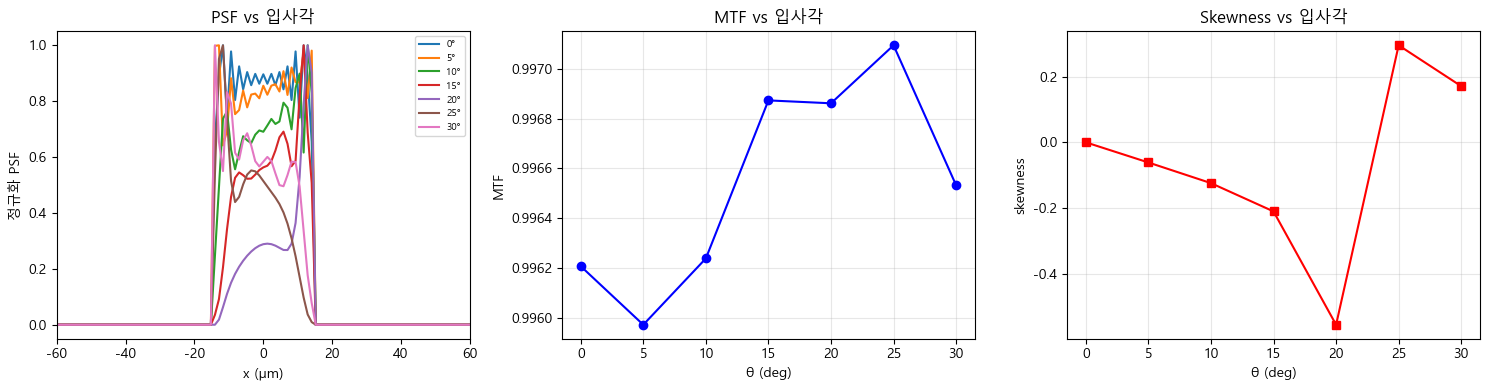

다각도 sweep 완료


In [3]:
# ===== 다각도 sweep =====
thetas = [0, 5, 10, 15, 20, 25, 30]
results_angle = []
for th in thetas:
    r = full_pipeline([1,1,1,1], 0.0, th)
    r['theta'] = th
    results_angle.append(r)
    print(f'theta={th:2d}  MTF={r["MTF"]:.4f}  T={r["T"]:.6f}  skew={r["skewness"]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PSF
ax = axes[0]
for r in results_angle:
    ax.plot(x, r['psf'] / (r['psf'].max() + 1e-30), label=f'{r["theta"]}\u00b0')
ax.set_xlabel('x (\u03bcm)')
ax.set_ylabel('정규화 PSF')
ax.set_title('PSF vs 입사각')
ax.legend(fontsize=7)
ax.set_xlim(-60, 60)

# MTF vs theta
ax = axes[1]
ax.plot(thetas, [r['MTF'] for r in results_angle], 'bo-')
ax.set_xlabel('\u03b8 (deg)')
ax.set_ylabel('MTF')
ax.set_title('MTF vs 입사각')
ax.grid(True, alpha=0.3)

# skewness vs theta
ax = axes[2]
ax.plot(thetas, [r['skewness'] for r in results_angle], 'rs-')
ax.set_xlabel('\u03b8 (deg)')
ax.set_ylabel('skewness')
ax.set_title('Skewness vs 입사각')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('통합_다각도_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('다각도 sweep 완료')

In [4]:
# ===== 5D BoTorch 최적화 세팅 =====
from scipy.stats import qmc

# 설계 변수 범위: d1~d4 in [0.7, 1.3], delta_bm in [-20, 30]
bounds_low = np.array([0.7, 0.7, 0.7, 0.7, -20.0])
bounds_high = np.array([1.3, 1.3, 1.3, 1.3, 30.0])
dim = 5

# LHS 초기 샘플 40개
sampler = qmc.LatinHypercube(d=dim, seed=42)
lhs_samples = sampler.random(n=40)
X_init = qmc.scale(lhs_samples, bounds_low, bounds_high)

# 평가 (theta=30)
THETA_OPT = 30.0
Y_list = []
print('초기 샘플 평가 중...')
t0 = time.time()
for i, xp in enumerate(X_init):
    d_sc = xp[:4].tolist()
    delta = float(xp[4])
    r = full_pipeline(d_sc, delta, THETA_OPT)
    # 목적: MTF(max), T(max), -|skew|(max)
    Y_list.append([r['MTF'], r['T'], -abs(r['skewness'])])

elapsed = time.time() - t0
print(f'초기 평가 완료: {elapsed:.1f}초 ({40}개 샘플)')

# Torch 테서 변환
train_X = torch.tensor(X_init, dtype=torch.float64)
train_Y = torch.tensor(np.array(Y_list), dtype=torch.float64)

# 정규ud654 bounds for BoTorch
bo_bounds = torch.tensor(
    [bounds_low.tolist(), bounds_high.tolist()],
    dtype=torch.float64
)

# Reference point (성능 하한)
ref_point = torch.tensor([0.0, 0.0, -5.0], dtype=torch.float64)

print(f'train_X shape: {train_X.shape}')
print(f'train_Y shape: {train_Y.shape}')
print(f'Y 범위:')
for i, name in enumerate(['MTF', 'T', '-|skew|']):
    print(f'  {name}: [{train_Y[:,i].min():.4f}, {train_Y[:,i].max():.4f}]')

초기 샘플 평가 중...
초기 평가 완료: 0.0초 (40개 샘플)
train_X shape: torch.Size([40, 5])
train_Y shape: torch.Size([40, 3])
Y 범위:
  MTF: [0.9958, 0.9993]
  T: [0.0010, 0.0946]
  -|skew|: [-3.1552, -0.0752]


In [5]:
# ===== qNEHVI 최적화 루프 =====
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.utils.multi_objective.hypervolume import Hypervolume
from botorch.utils.sampling import draw_sobol_samples
from botorch.utils.transforms import normalize, unnormalize

try:
    from botorch.acquisition.multi_objective.logei import (
        qLogNoisyExpectedHypervolumeImprovement
    )
    AcqClass = qLogNoisyExpectedHypervolumeImprovement
    print('qLogNEHVI 사용')
except ImportError:
    from botorch.acquisition.multi_objective.monte_carlo import (
        qNoisyExpectedHypervolumeImprovement
    )
    AcqClass = qNoisyExpectedHypervolumeImprovement
    print('qNEHVI 사용 (fallback)')

from botorch.optim import optimize_acqf

hv_calculator = Hypervolume(ref_point=ref_point)
N_ITER = 20
BATCH_Q = 3

hv_history = []

# 초기 하이퍼볼륨
pareto_mask = torch.ones(train_Y.shape[0], dtype=torch.bool)
hv0 = hv_calculator.compute(train_Y[pareto_mask])
hv_history.append(hv0)
print(f'초기 HV = {hv0:.6f}')

t_start = time.time()

for iteration in range(N_ITER):
    # GP 모델 학습
    model = SingleTaskGP(
        train_X, train_Y,
        outcome_transform=Standardize(m=3)
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # Acquisition function
    acq = AcqClass(
        model=model,
        ref_point=ref_point.tolist(),
        X_baseline=train_X,
        prune_baseline=True,
    )

    # 최적화
    candidates, acq_val = optimize_acqf(
        acq_function=acq,
        bounds=bo_bounds,
        q=BATCH_Q,
        num_restarts=8,
        raw_samples=256,
    )

    # 후보 평가
    new_Y_list = []
    for c in candidates:
        cp = c.detach().numpy()
        d_sc = cp[:4].tolist()
        delta = float(cp[4])
        r = full_pipeline(d_sc, delta, THETA_OPT)
        new_Y_list.append([r['MTF'], r['T'], -abs(r['skewness'])])

    new_Y = torch.tensor(new_Y_list, dtype=torch.float64)

    # 데이터 추가
    train_X = torch.cat([train_X, candidates], dim=0)
    train_Y = torch.cat([train_Y, new_Y], dim=0)

    # 하이퍼볼륨 계산
    hv_val = hv_calculator.compute(train_Y)
    hv_history.append(hv_val)

    elapsed = time.time() - t_start
    print(f'Iter {iteration+1:2d}/{N_ITER} | HV={hv_val:.6f} | '
          f'best MTF={train_Y[:,0].max():.4f} | '
          f'best T={train_Y[:,1].max():.6f} | '
          f'time={elapsed:.0f}s')

total_time = time.time() - t_start
print(f'\n최적화 완료: 총 {total_time:.1f}초, 최종 HV={hv_history[-1]:.6f}')

qLogNEHVI 사용
초기 HV = 0.463597
Iter  1/20 | HV=0.463597 | best MTF=0.9993 | best T=0.094578 | time=30s
Iter  2/20 | HV=0.463638 | best MTF=0.9993 | best T=0.094578 | time=51s
Iter  3/20 | HV=0.463641 | best MTF=0.9993 | best T=0.094578 | time=76s
Iter  4/20 | HV=0.463641 | best MTF=0.9993 | best T=0.094578 | time=113s
Iter  5/20 | HV=0.463642 | best MTF=0.9993 | best T=0.094578 | time=202s
Iter  6/20 | HV=0.463656 | best MTF=0.9993 | best T=0.094578 | time=238s
Iter  7/20 | HV=0.463656 | best MTF=0.9993 | best T=0.094578 | time=276s
Iter  8/20 | HV=0.463656 | best MTF=0.9993 | best T=0.094578 | time=330s
Iter  9/20 | HV=0.463659 | best MTF=0.9993 | best T=0.094578 | time=384s
Iter 10/20 | HV=0.463659 | best MTF=0.9993 | best T=0.094578 | time=438s
Iter 11/20 | HV=0.463667 | best MTF=0.9993 | best T=0.094578 | time=506s
Iter 12/20 | HV=0.463667 | best MTF=0.9993 | best T=0.094578 | time=567s
Iter 13/20 | HV=0.463667 | best MTF=0.9993 | best T=0.094578 | time=635s
Iter 14/20 | HV=0.463667

Best design (idx=96):
  d_scales = [0.7000, 1.3000, 0.7000, 1.3000]
  delta_bm = -20.00 um
  MTF=0.9978, T=0.073209, skew=0.0752


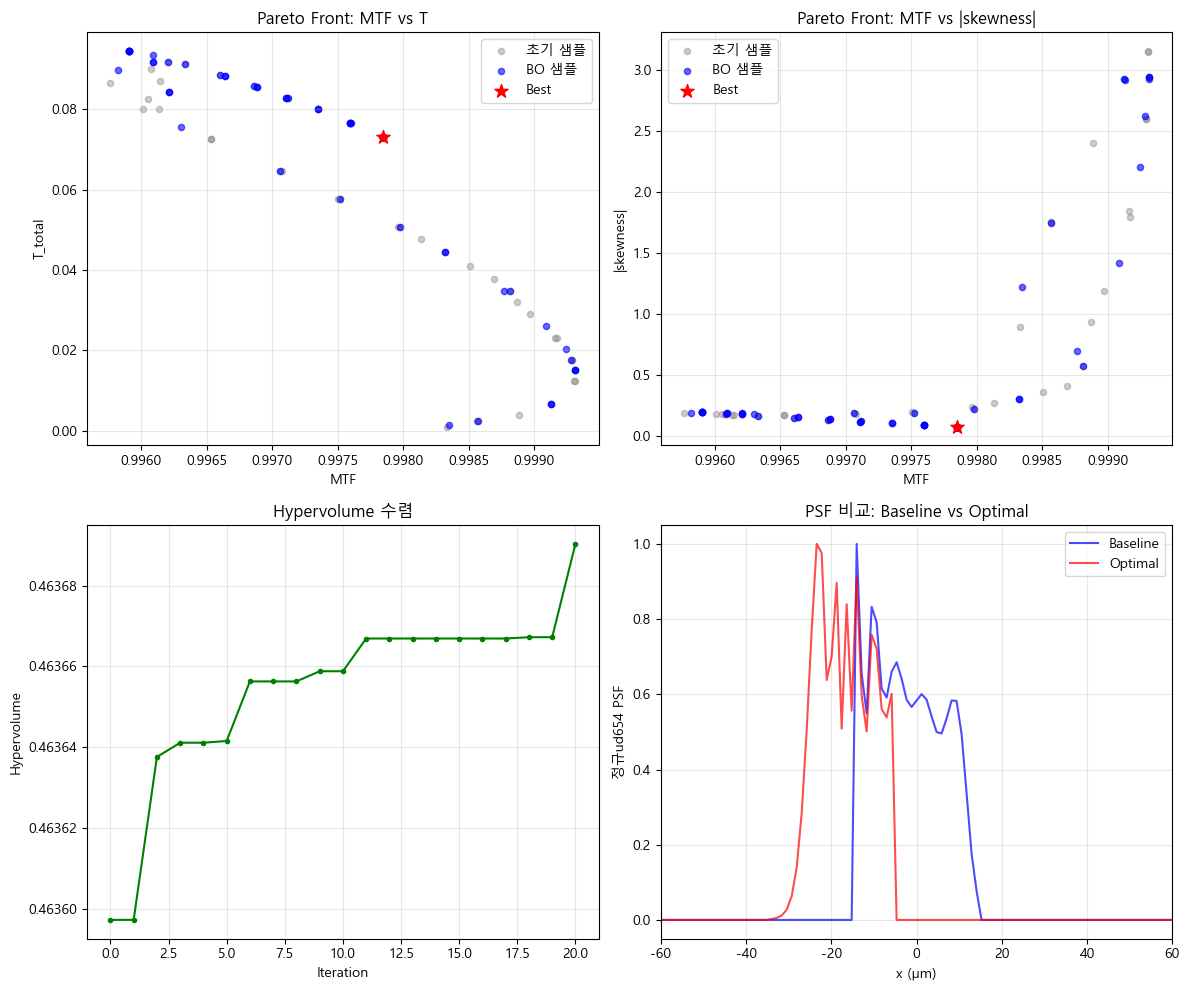

결과 시각화 완료


In [6]:
# ===== 결과 시각화 =====
Y_np = train_Y.numpy()

# 가중 점수로 best 선택 (MTF*0.4 + T*0.3 + (1-|skew|)*0.3)
scores = 0.4 * Y_np[:, 0] + 0.3 * Y_np[:, 1] + 0.3 * (1 + Y_np[:, 2])
best_idx = np.argmax(scores)
best_x = train_X[best_idx].numpy()
best_y = Y_np[best_idx]

print(f'Best design (idx={best_idx}):')
print(f'  d_scales = [{best_x[0]:.4f}, {best_x[1]:.4f}, {best_x[2]:.4f}, {best_x[3]:.4f}]')
print(f'  delta_bm = {best_x[4]:.2f} um')
print(f'  MTF={best_y[0]:.4f}, T={best_y[1]:.6f}, skew={-best_y[2]:.4f}')

# 최적 설계 PSF
res_opt = full_pipeline(best_x[:4].tolist(), float(best_x[4]), THETA_OPT)
res_base = full_pipeline([1,1,1,1], 0.0, THETA_OPT)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Pareto: MTF vs T
ax = axes[0, 0]
ax.scatter(Y_np[:40, 0], Y_np[:40, 1], c='gray', alpha=0.4, s=20, label='초기 샘플')
ax.scatter(Y_np[40:, 0], Y_np[40:, 1], c='blue', alpha=0.6, s=20, label='BO 샘플')
ax.scatter(best_y[0], best_y[1], c='red', s=100, marker='*', label='Best', zorder=5)
ax.set_xlabel('MTF')
ax.set_ylabel('T_total')
ax.set_title('Pareto Front: MTF vs T')
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Pareto: MTF vs |skew|
ax = axes[0, 1]
ax.scatter(Y_np[:40, 0], -Y_np[:40, 2], c='gray', alpha=0.4, s=20, label='초기 샘플')
ax.scatter(Y_np[40:, 0], -Y_np[40:, 2], c='blue', alpha=0.6, s=20, label='BO 샘플')
ax.scatter(best_y[0], -best_y[2], c='red', s=100, marker='*', label='Best', zorder=5)
ax.set_xlabel('MTF')
ax.set_ylabel('|skewness|')
ax.set_title('Pareto Front: MTF vs |skewness|')
ax.legend()
ax.grid(True, alpha=0.3)

# 3) HV convergence
ax = axes[1, 0]
ax.plot(range(len(hv_history)), hv_history, 'g.-')
ax.set_xlabel('Iteration')
ax.set_ylabel('Hypervolume')
ax.set_title('Hypervolume 수렴')
ax.grid(True, alpha=0.3)

# 4) PSF 비교: baseline vs optimal
ax = axes[1, 1]
psf_base_n = res_base['psf'] / (res_base['psf'].max() + 1e-30)
psf_opt_n = res_opt['psf'] / (res_opt['psf'].max() + 1e-30)
ax.plot(x, psf_base_n, 'b-', alpha=0.7, label='Baseline')
ax.plot(x, psf_opt_n, 'r-', alpha=0.7, label='Optimal')
ax.set_xlabel('x (\u03bcm)')
ax.set_ylabel('정규ud654 PSF')
ax.set_title('PSF 비교: Baseline vs Optimal')
ax.legend()
ax.set_xlim(-60, 60)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('통합_최적화_결과.png', dpi=150, bbox_inches='tight')
plt.show()
print('결과 시각화 완료')

In [7]:
# ===== 결과 저장 및 요약 =====

# 최적 설계 두께 (um)
opt_thick_um = (BASE_THICK_UM * best_x[:4]).tolist()

result_dict = {
    'design': {
        'd_scales': best_x[:4].tolist(),
        'd_thick_um': opt_thick_um,
        'delta_bm_um': float(best_x[4]),
        'layer_materials': ['SiO2', 'TiO2', 'SiO2', 'TiO2'],
        'layer_n': N_LAYERS
    },
    'performance': {
        'MTF': float(res_opt['MTF']),
        'T_total': float(res_opt['T']),
        'skewness': float(res_opt['skewness']),
        'abs_skewness': float(abs(res_opt['skewness']))
    },
    'baseline': {
        'MTF': float(res_base['MTF']),
        'T_total': float(res_base['T']),
        'skewness': float(res_base['skewness'])
    },
    'optimization': {
        'n_init': 40,
        'n_iter': N_ITER,
        'batch_q': BATCH_Q,
        'total_evals': int(train_X.shape[0]),
        'final_hypervolume': float(hv_history[-1]),
        'theta_deg': THETA_OPT
    },
    'parameters': {
        'wavelength_um': WAVELENGTH,
        'CG_thick_um': CG_THICK,
        'n_CG': N_CG,
        'w1_um': w1,
        'w2_um': w2,
        't_BM_um': t_BM,
        'd_int_um': d_int,
        'grid_N': N,
        'grid_L_um': L
    }
}

with open('integrated_optimal.json', 'w', encoding='utf-8') as f:
    json.dump(result_dict, f, indent=2, ensure_ascii=False)
print('integrated_optimal.json 저장 완료')

# 비교 테이블
print('\n' + '='*60)
print('         Baseline  vs  Optimal')
print('='*60)
print(f'{"MTF":>12s}:  {res_base["MTF"]:8.4f}    {res_opt["MTF"]:8.4f}')
print(f'{"T_total":>12s}:  {res_base["T"]:8.6f}    {res_opt["T"]:8.6f}')
print(f'{"skewness":>12s}:  {res_base["skewness"]:8.4f}    {res_opt["skewness"]:8.4f}')
print(f'{"|skewness|":>12s}:  {abs(res_base["skewness"]):8.4f}    {abs(res_opt["skewness"]):8.4f}')
print('='*60)

print(f'\n최적 AR 코팅 두께 (nm):')
for i, (mat, t) in enumerate(zip(['SiO2', 'TiO2', 'SiO2', 'TiO2'], opt_thick_um)):
    base_nm = BASE_THICK_UM[i] * 1000
    opt_nm = t * 1000
    print(f'  Layer {i+1} ({mat}): {base_nm:.1f} nm -> {opt_nm:.1f} nm (x{best_x[i]:.3f})')

print(f'\nBM1 오프셋: 0.0 um -> {best_x[4]:.2f} um')
print(f'\n파이프라인: TMM -> ASM(CG {CG_THICK}um) -> BM2 -> ASM(BM {d_int+t_BM}um) -> BM1 -> PSF')
print(f'최적화 완료: 총 {train_X.shape[0]}회 평가, HV={hv_history[-1]:.6f}')

integrated_optimal.json 저장 완료

         Baseline  vs  Optimal
         MTF:    0.9965      0.9978
     T_total:  0.072558    0.073209
    skewness:    0.1706      0.0752
  |skewness|:    0.1706      0.0752

최적 AR 코팅 두께 (nm):
  Layer 1 (SiO2): 49.5 nm -> 34.6 nm (x0.700)
  Layer 2 (TiO2): 19.9 nm -> 25.9 nm (x1.300)
  Layer 3 (SiO2): 29.6 nm -> 20.7 nm (x0.700)
  Layer 4 (TiO2): 130.4 nm -> 169.5 nm (x1.300)

BM1 오프셋: 0.0 um -> -20.00 um

파이프라인: TMM -> ASM(CG 550.0um) -> BM2 -> ASM(BM 30.0um) -> BM1 -> PSF
최적화 완료: 총 100회 평가, HV=0.463690
